In [2]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
from riap.api import load_config, Riap

### 1. Initiate the analyzer

In [3]:
# 1. using a config gfile
cfg = load_config("IMPV1.yaml")
# riap_analyser = Riap(cfg)

# 2. overriding specific parameters
riap_analyser = Riap(
    cfg,
    data_path = "/home/elea/Documents/HORAO/PROJECTS/5_RIAP/data/measurements/",
    path_output = "/home/elea/Documents/HORAO/PROJECTS/5_RIAP/data/results/",
    alignment_method = "MatchAnything"
)

2026-03-01 00:20:05.943 | INFO     | riap.api:__init__:79 - Data path set to: /home/elea/Documents/HORAO/PROJECTS/5_RIAP/data/measurements
2026-03-01 00:20:05.944 | INFO     | riap.api:__init__:128 - Alignment method set to: MatchAnything
2026-03-01 00:20:05.944 | INFO     | riap.api:__init__:135 - Output path set to: /home/elea/Documents/HORAO/PROJECTS/5_RIAP/data/results
2026-03-01 00:20:05.945 | INFO     | riap.api:__init__:157 - Force recompute set to: False
2026-03-01 00:20:05.945 | INFO     | riap.api:__init__:162 - Input parameters validated successfully
2026-03-01 00:20:05.945 | INFO     | riap.api:__init__:163 - Riap instance initiated successfully

2026-03-01 00:20:05.946 | INFO     | riap.api:__init__:168 - Alignment folders will be available in: /home/elea/Documents/HORAO/PROJECTS/5_RIAP/temp
2026-03-01 00:20:05.946 | INFO     | riap.api:__init__:171 - Base directories identified: ['/home/elea/Documents/HORAO/PROJECTS/5_RIAP/data/measurements/2025-06-05_T_CALF_FR_T0_S5_1']


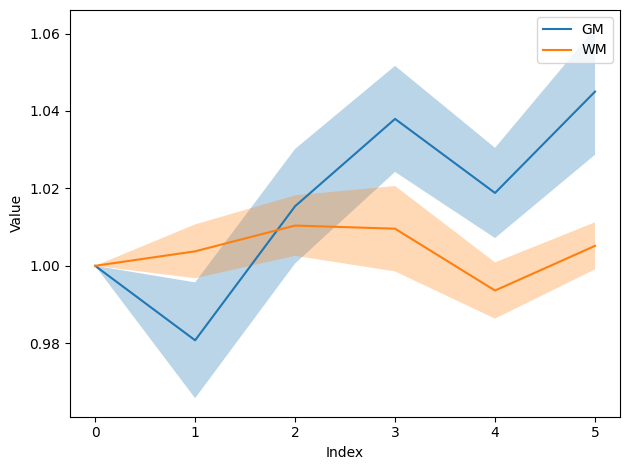

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to your Excel file
file_path = riap_analyser.output_path / "totP_prism_cv.xlsx"  # adjust if needed

# Load Excel file (first column is index)
df = pd.read_excel(file_path)#, index_col=0)

# Split columns into two conditions
num_columns = df.shape[1]
split_index = num_columns // 2

condition1 = df.iloc[:, :split_index]
condition2 = df.iloc[:, split_index:]

# Number of samples per condition
n1 = condition1.shape[1]
n2 = condition2.shape[1]

# Row-wise statistics
mean1 = condition1.mean(axis=1) 
std1 = condition1.std(axis=1)
sem1 = std1 / np.sqrt(n1)
ci1 = 1.96 * sem1

mean2 = condition2.mean(axis=1)
std2 = condition2.std(axis=1)
sem2 = std2 / np.sqrt(n2)
ci2 = 1.96 * sem2

# Plot
plt.figure()

# Condition 1
plt.plot(df.index, mean1, linestyle='-', label = 'GM')
plt.fill_between(df.index, mean1 - ci1, mean1 + ci1, alpha=0.3)

# Condition 2
plt.plot(df.index, mean2, linestyle='-', label = 'WM')
plt.fill_between(df.index, mean2 - ci2, mean2 + ci2, alpha=0.3)

plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

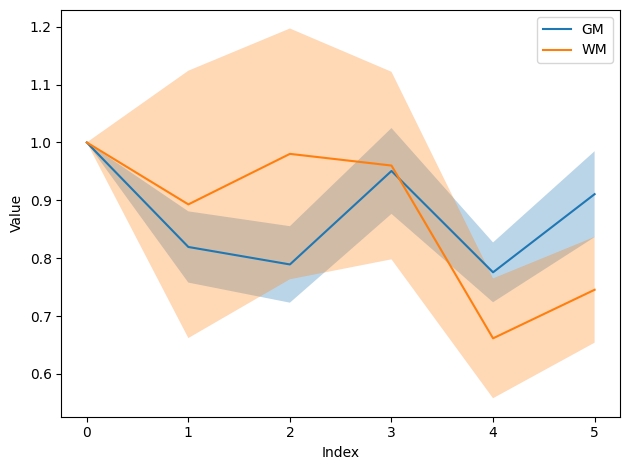

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to your Excel file
file_path = riap_analyser.output_path / "linR_prism_cv.xlsx"  # adjust if needed
# Load Excel file (first column is index)
df = pd.read_excel(file_path)# , index_col=0)

# Split columns into two conditions
num_columns = df.shape[1]
split_index = num_columns // 2

condition1 = df.iloc[:, :split_index]
condition2 = df.iloc[:, split_index:]

# Number of samples per condition
n1 = condition1.shape[1]
n2 = condition2.shape[1]

# Row-wise statistics
mean1 = condition1.mean(axis=1) 
std1 = condition1.std(axis=1)
sem1 = std1 / np.sqrt(n1)
ci1 = 1.96 * sem1

mean2 = condition2.mean(axis=1)
std2 = condition2.std(axis=1)
sem2 = std2 / np.sqrt(n2)
ci2 = 1.96 * sem2

# Plot
plt.figure()

# Condition 1
plt.plot(df.index, mean1, linestyle='-', label = 'GM')
plt.fill_between(df.index, mean1 - ci1, mean1 + ci1, alpha=0.3)

# Condition 2
plt.plot(df.index, mean2, linestyle='-', label = 'WM')
plt.fill_between(df.index, mean2 - ci2, mean2 + ci2, alpha=0.3)

plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()